# **AI Agent_Agentic RAG**

## **1.환경준비**

### (1) 구글 드라이브

#### 1) 구글 드라이브 폴더 생성
* 새 폴더(LangGraph)를 생성하고
* 제공 받은 파일을 업로드

#### 2) 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### (2) 라이브러리

#### 1) 필요한 라이브러리 설치

In [ ]:
!pip install langchain langgraph typing typing_extensions langchain-openai langchain_core langchain-community wikipedia chromadb google-search-results -q

#### 2) 라이브러리 로딩

In [ ]:
import pandas as pd
import numpy as np
import os
import openai

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from typing import Annotated, Literal, Sequence, TypedDict
from langchain import hub
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from langchain.embeddings import OpenAIEmbeddings
from langchain.vectorstores import Chroma
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from langgraph.prebuilt import tools_condition

### (3) OpenAI API Key 확인

In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/LangGraph/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [ ]:
print(os.environ['OPENAI_API_KEY'][:30])

## 2.Agentic RAG 구현해보기

**기존 RAG 한계점**
- 사용자의 질문이 인덱싱 된 문서와 관련이 없는 경우에도 Retrieval 단계를 거침
- 검색된 문서가 사용자의 질문과 관련성이 없는 경우에도 이를 활용해 답변하려고 하기 때문에 환각 현상 크게 증가

**이를 보완하기 위해 GPT 기반 Agent적 사고와 제어 흐름을 결합한 Agentic RAG 사용**



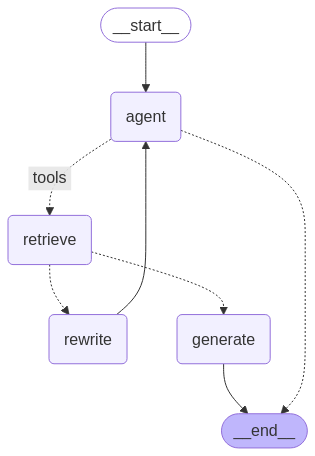

### (1) VectorDB 준비(retriever)

In [ ]:
from langchain.document_loaders import CSVLoader

# CSV 파일 로드
csv_path = path + "sample.csv"
csv_loader = CSVLoader(file_path=csv_path)
documents_csv = csv_loader.load()

# 벡터 DB 정의
embedding = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = Chroma.from_documents(documents_csv, embedding,
                                    persist_directory="chroma_db")

retriever = vectorstore.as_retriever()

In [ ]:
from langchain.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_blog_posts",    # 함수 이름은 영문, 띄어쓰기 없어야함.
    '''Search and return information about Lilian Weng blog posts on LLM agents,
     prompt engineering, and adversarial attacks on LLMs.''',
)

tools = [retriever_tool]

In [ ]:
retriever_tool.invoke("What is the agent?")

### (2) Agentic RAG 노드 및 엣지 정의

#### 1) Agent의 상태 정의

Agent는 메시지를 상태로 저장하고, 새로운 메시지가 추가될 때마다 업데이트합니다.


In [ ]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

- AgentState: 시스템이 다루는 상태 정보를 정의 (메시지 리스트)
- add_messages: 기존 메시지 목록을 유지하면서 새로운 메시지를 추가 (덮어쓰기 X)


#### 2) Agent가 검색할지 여부 결정 (agent)

Agent는 검색이 필요한지 판단하고, 검색 도구를 실행할지 결정합니다.

In [ ]:
def agent(state):
    """
    Agent 모델을 실행하여 검색할지 결정합니다.
    """
    print("---Agent 실행---")

    messages = state["messages"]
    model = ChatOpenAI(temperature=0, streaming=True, model="gpt-4.1-mini")

    # 검색 도구를 Agent와 연결
    model = model.bind_tools(tools)

    # Agent 실행
    response = model.invoke(messages)

    # 새로운 응답 메시지를 상태에 추가하여 반환
    return {"messages": [response]}


#### 3) 검색된 문서의 적절성 평가 (grade_documents)

검색된 문서가 질문과 관련이 있는지 판단하는 노드입니다.

In [ ]:
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    검색된 문서가 사용자 질문과 관련이 있는지 판단합니다.
    - 관련성이 높으면 'generate' (답변 생성)으로 이동
    - 관련성이 낮으면 'rewrite' (검색어 개선)으로 이동
    """

    print("---검색된 문서의 적절성 평가 수행---")

    # 결과가 yes, no 로만 나오도록 출력 정의
    class grade(BaseModel):
        """검색된 문서의 적절성을 평가하는 이진 점수 (yes 또는 no)"""
        binary_score: str = Field(description="검색된 문서의 적절성 점수 (예: 'yes' 또는 'no')")

    # OpenAI gpt-4.1-mini 모델 설정
    model = ChatOpenAI(temperature=0, model="gpt-4.1-mini", streaming=True)
    llm_with_tool = model.with_structured_output(grade)

    # 프롬프트 템플릿 정의
    prompt = PromptTemplate(
        template="""당신은 검색된 문서가 사용자 질문과 관련이 있는지 평가하는 역할을 수행합니다.
        다음은 검색된 문서입니다: \n\n {context} \n\n
        다음은 사용자 질문입니다: {question} \n
        문서가 질문과 관련된 키워드나 의미를 포함하고 있다면 'yes', 아니라면 'no'를 출력하세요.""",
        input_variables=["context", "question"],
    )

    # 체인 실행
    chain = prompt | llm_with_tool
    messages = state["messages"]
    last_message = messages[-1]  # 최근 메시지 (검색된 문서)
    question = messages[0].content  # 원본 질문

    # 검색된 문서와 질문을 LLM에 입력하여 적절성 평가 수행
    scored_result = chain.invoke({"question": question, "context": last_message.content})
    score = scored_result.binary_score

    # 문서가 적절하면 답변 생성(generate), 그렇지 않으면 검색어 개선(rewrite)
    if score == "yes":
        print("---결정: 문서가 관련 있음 (답변 생성으로 이동)---")
        return "generate"
    else:
        print("---결정: 문서가 관련 없음 (검색어 개선으로 이동)---")
        return "rewrite"


#### 4) 검색어 개선 (rewrite)

검색된 문서가 적절하지 않다면, 검색어를 개선하여 다시 검색합니다.

In [ ]:
def rewrite(state):
    """
    검색어를 보다 적절하게 변경하여 검색 성능을 향상시킵니다.
    """
    print("---검색어 개선 수행---")

    messages = state["messages"]
    question = messages[0].content

    # 검색어 개선을 위한 메시지 생성
    msg = [
        HumanMessage(
            content=f"""
    입력된 질문을 보고 의미적으로 더 적절한 표현을 찾아보세요.
    다음은 원본 질문입니다:
    {question}
    더 나은 검색어로 변환하세요:
            """
        )
    ]

    # 검색어 개선 수행
    model = ChatOpenAI(temperature=0, model="gpt-4.1-mini", streaming=True)
    response = model.invoke(msg)

    return {"messages": [response]}


#### 5) 답변 생성 (generate)

In [ ]:
from langchain import hub
from langchain_core.output_parsers import StrOutputParser
from langchain.prompts import ChatPromptTemplate

def generate(state):
    """
    검색된 문서를 기반으로 답변을 생성합니다.
    """
    print("---답변 생성 시작---")

    messages = state["messages"]
    question = messages[0].content             # 사용자의 질문
    last_message = messages[-1]                # ToolMessage (검색 결과)
    docs = last_message.content                # 검색된 문서 내용 (text)

    # 프롬프트 가져오기
    prompt = ChatPromptTemplate.from_template(
        '''You are an assistant for question-answering tasks.
        Use the following pieces of retrieved context to answer the question.
        If you don't know the answer, just say that you don't know.
        Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:'''
    )
    formatted_prompt = prompt.format(question=question, context = docs)

    llm = ChatOpenAI(model_name="gpt-4.1-mini", temperature=0, streaming=True)


    # RAG 실행 체인
    rag_chain = prompt | llm | StrOutputParser()

    # 최종 답변 생성
    response = rag_chain.invoke(formatted_prompt)

    return {"messages": [AIMessage(content=response)]}


### (3) 그래프 구축 및 실행

In [ ]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

# 새로운 상태 그래프 정의
workflow = StateGraph(AgentState)

# 노드 추가
workflow.add_node("agent", agent)
retrieve = ToolNode([retriever_tool])
workflow.add_node("retrieve", retrieve)
workflow.add_node("rewrite", rewrite)
workflow.add_node("generate", generate)

# 엣지 추가: Agent → 검색 또는 종료
workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", tools_condition, {"tools": "retrieve", END: END})
workflow.add_conditional_edges("retrieve", grade_documents)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# 그래프 컴파일
graph = workflow.compile()


* 시각화

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

### (4) 실행

In [ ]:
import pprint

inputs = {
    "messages": [
        ("user", "What does Lilian Weng say about the types of agent memory?"),
    ]
}
for output in graph.stream(inputs):
    for key, value in output.items():
        pprint.pprint(f"Output from node '{key}':")
        pprint.pprint("---")
        pprint.pprint(value, indent=2, width=80, depth=None)
    pprint.pprint("\n---\n")

In [ ]:
result = graph.invoke(inputs)

In [ ]:
result['messages']

In [ ]:
for message in result["messages"]:
    message.pretty_print()